In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import rc

rc('text', usetex=True)
rc('font', **{'family': 'sans-serif', 'sans-serif': ['Helvetica'],
              'weight': 'bold', 'size': 16})

# Z4 PRS fat-wall scan — analysis

Analysis of the **PRS (Press–Ryden–Spergel) fat-wall** Z4 domain-wall runs produced last
session. Same output format as `Z4_scan_analysis.ipynb`, but a different scan and
parameterization.

**Provenance** (do *not* re-run from here unless you mean to):
- Boxes sized by `analysis/wall_width_box_calculator_Z4.ipynb` (BVP wall widths → `lSide`, `tMax`).
- Cards in `src/models/parameter-files/scan_z4_prs/` (`prsWall=true`, `prsDamping=1.0`).
- Launched with `buildZ4_stable/runner_stable.sh`; logs in `buildZ4_stable/logs/scan/`.
- Outputs in `/mt/user-batch/dpasari/scan_z4_prs/`.

**Scan grid**
- `mu = 0.01`  (fixed physical mass scale)
- `beta_4 = 2 λ₂/λ₁` : `[0.01, 0.10, 0.25, 0.50, 0.75, 0.90]` — Z4-breaking strength, strictly in (0,1)
- Fixed: `H0 = 1.0·mu`, `kCutOff = 3`, `N = 512`
- **`lSide` (box) varies per `beta_4`** — each box is sized to 2 grid points across the thinnest
  wall (`delta_bar_min`), so `dx = lSide/N` changes between runs.

**Model** (reparameterized 2026-05-28):
$$V = -\mu^2|\Phi|^2 + \lambda_1|\Phi|^4 - \lambda_2(\Phi^4+\Phi^{*4}),\qquad v=1
\;\Rightarrow\; \lambda_1=\frac{\mu^2}{1-\beta_4},\; \lambda_2=\frac{\beta_4\,\mu^2}{2(1-\beta_4)}.$$

Output columns in `average_energies.txt` (standard 9 + 2 wall observables):
- Column 10 → `Scal_type_1` (adjacent walls, θ → θ+π/2)
- Column 11 → `Scal_type_2` (diagonal walls, θ → θ+π)

> **PRS caveat.** Under `prsWall=true` the comoving wall width is held *fixed*, so the physical
> width grows ∝ a. The geometric wall-area observable 𝒜 (`Scal_type_*`, from `ZNvacuumPhase`)
> stays valid and is the quantity to use for scaling. Wall tension σ and the GW-UV spectrum from
> these runs are **unphysical** — take σ from the static BVP tensions instead.

In [ ]:
BASE     = "/mt/user-batch/dpasari/scan_z4_prs_diag/"
H0_RATIO = 1.0

MU         = 0.01                                   # fixed mass scale
BETA4_VALS = [0.01, 0.10, 0.25, 0.50, 0.75, 0.90]   # beta_4 = 2 lambda2/lambda1 in (0,1)
KCUTOFF    = 3                                       # fixed IR cutoff

# ── Lattice (N fixed; lSide/dx are PER-beta_4, read from each run's DWZ4.infos) ─
N_LAT       = 512
N_PTS_WALL  = 2          # grid points across the thinnest wall used when sizing the box

# ── PRS / friction settings written into every card (for reference) ───────────
PRS_WALL, PRS_DAMPING, FRICTION_GAMMA, FRICTION_END_A = True, 1.0, 0.0, 3.0

# ── Encoding: colour = beta_4 (single mu, single k) ───────────────────────────
beta4_colors = plt.cm.plasma(np.linspace(0.08, 0.88, len(BETA4_VALS)))
beta4_color  = {b: beta4_colors[i] for i, b in enumerate(BETA4_VALS)}

def float_str(x):
    return f"{x:g}".replace(".", "p")

def h0_label(ratio):
    return f"H{f'{ratio:g}'.replace('.', 'p')}mu"

def couplings_from_mu_beta4(mu, beta4):
    # V = -mu^2|Phi|^2 + lambda1|Phi|^4 - lambda2(Phi^4+Phi*^4), unit vev v=1
    assert 0.0 < beta4 < 1.0, beta4
    lambda1 = mu * mu / (1.0 - beta4)
    lambda2 = beta4 * mu * mu / (2.0 * (1.0 - beta4))
    return lambda1, lambda2

def result_dir(beta4):
    return (f"{BASE}results_DWZ4_b4{float_str(beta4)}_"
            f"{h0_label(H0_RATIO)}_k{KCUTOFF}_prs/")

# ── Wall widths (program units; delta_bar = mu*delta_phys is dimensionless) ────
# Adjacent (type-1) delta_bar_adj(beta_4) and tension sigma_bar_adj from the 2-field
# BVP in wall_width_box_calculator_Z4.ipynb (continuation from beta=1/3). Diagonal
# (type-2) width is beta-independent. These set the box sizes used in the scan.
DELTA_OPP = 1.40                                                              # type-2 width
DELTA_ADJ = {0.01: 6.530, 0.10: 2.380, 0.25: 1.571, 0.50: 1.220, 0.75: 1.098, 0.90: 1.087}
SIGMA_ADJ = {0.01: 0.116, 0.10: 0.323, 0.25: 0.564, 0.50: 1.098, 0.75: 2.601, 0.90: 7.268}

def delta_adj(b): return DELTA_ADJ[b]
def delta_min(b): return min(DELTA_ADJ[b], DELTA_OPP)   # thinnest wall present -> sets dx

print(f"{'beta_4':>7s} {'lambda1':>11s} {'lambda2':>12s} "
      f"{'d_adj':>6s} {'d_opp':>6s} {'d_min':>6s}")
for b in BETA4_VALS:
    l1, l2 = couplings_from_mu_beta4(MU, b)
    print(f"{b:7.2f} {l1:11.6e} {l2:12.6e} "
          f"{delta_adj(b):6.3f} {DELTA_OPP:6.3f} {delta_min(b):6.3f}")

 beta_4     lambda1      lambda2  d_adj  d_opp  d_min
   0.01 1.010101e-04 5.050505e-07  6.530  1.400  1.400
   0.10 1.111111e-04 5.555556e-06  2.380  1.400  1.400
   0.25 1.333333e-04 1.666667e-05  1.571  1.400  1.400
   0.50 2.000000e-04 5.000000e-05  1.220  1.400  1.220
   0.75 4.000000e-04 1.500000e-04  1.098  1.400  1.098
   0.90 1.000000e-03 4.500000e-04  1.087  1.400  1.087


## Loader functions

In [3]:
def load_energies(path):
    """
    Load average_energies.txt for the Z4 model.
    Fixed columns (9): t, Ek_1, Ek_2, Eg_1, Eg_2, Ev_1, Ev_2, Ev_3, E_tot
    Wall columns (2):  Scal_type_1 (adjacent), Scal_type_2 (diagonal)
    """
    fpath = os.path.join(path, "average_energies.txt")
    try:
        data = np.loadtxt(fpath)
    except (FileNotFoundError, OSError):
        print(f"[load_energies] NOT FOUND: {fpath}")
        return None
    if data.ndim == 1:
        data = data[np.newaxis, :]
    if data.shape[1] < 11:
        print(f"[load_energies] Only {data.shape[1]} columns — wall columns missing? ({fpath})")
        return None
    return {
        "eta":   data[:, 0],
        "Ek_1":  data[:, 1], "Ek_2": data[:, 2],
        "Eg_1":  data[:, 3], "Eg_2": data[:, 4],
        "Ev_1":  data[:, 5], "Ev_2": data[:, 6], "Ev_3": data[:, 7],
        "E_tot": data[:, 8],
        "scal1": data[:, 9],    # Scal_type_1 (adjacent)
        "scal2": data[:, 10],   # Scal_type_2 (diagonal)
    }


def load_scalar(path, idx):
    """Load average_scalar_{idx}.txt."""
    fpath = os.path.join(path, f"average_scalar_{idx}.txt")
    try:
        data = np.loadtxt(fpath)
    except (FileNotFoundError, OSError):
        return None
    if data.ndim == 1:
        data = data[np.newaxis, :]
    return {
        "eta": data[:, 0], "phi": data[:, 1], "phi_prime": data[:, 2],
        "phi2": data[:, 3], "phi_prime2": data[:, 4],
        "rms_phi": data[:, 5], "rms_phi_p": data[:, 6],
    }


def load_scale_factor(path):
    """Load average_scale_factor.txt."""
    fpath = os.path.join(path, "average_scale_factor.txt")
    try:
        data = np.loadtxt(fpath)
    except (FileNotFoundError, OSError):
        return None
    if data.ndim == 1:
        data = data[np.newaxis, :]
    return {"eta": data[:, 0], "a": data[:, 1], "aprime": data[:, 2], "H": data[:, 3]}


def load_lside(path):
    """Read lSide (program units) from DWZ4.infos — boxes differ per beta_4."""
    fpath = os.path.join(path, "DWZ4.infos")
    try:
        with open(fpath) as f:
            for line in f:
                p = line.split()
                if len(p) >= 2 and p[0] == "lSide":
                    return float(p[1])
    except (FileNotFoundError, OSError):
        return None
    return None

## Load all runs

In [4]:
datasets = []

for beta4 in BETA4_VALS:
    lambda1, lambda2 = couplings_from_mu_beta4(MU, beta4)
    path  = result_dir(beta4)
    label = rf"$\beta_4 = {beta4}$"

    en = load_energies(path)
    sf = load_scale_factor(path)
    s0 = load_scalar(path, 0)
    s1 = load_scalar(path, 1)
    lside = load_lside(path)
    dx    = (lside / N_LAT) if lside else np.nan

    status = "OK" if (en is not None and sf is not None) else "MISSING"
    print(f"{status:7s} {label:16s}  lSide={lside!s:>9}  dx={dx:.4f}  {path}")

    datasets.append({
        "label": label, "beta4": beta4, "mu": MU, "kcutoff": KCUTOFF,
        "lambda1": lambda1, "lambda2": lambda2,
        "lside": lside, "dx": dx,
        "color": beta4_color[beta4], "lw": 2.5,
        "energies": en, "scale_factor": sf, "scalar_0": s0, "scalar_1": s1,
    })

ready = [d for d in datasets if d["energies"] is not None and d["scale_factor"] is not None]
print(f"\nReady: {len(ready)} / {len(datasets)}")

OK      $\beta_4 = 0.01$  lSide=    358.4  dx=0.7000  /mt/user-batch/dpasari/scan_z4_prs/results_z4_mu0p01_beta40p01_H1mu_k3_prs/
OK      $\beta_4 = 0.1$   lSide=    358.4  dx=0.7000  /mt/user-batch/dpasari/scan_z4_prs/results_z4_mu0p01_beta40p1_H1mu_k3_prs/
OK      $\beta_4 = 0.25$  lSide=    358.4  dx=0.7000  /mt/user-batch/dpasari/scan_z4_prs/results_z4_mu0p01_beta40p25_H1mu_k3_prs/
OK      $\beta_4 = 0.5$   lSide= 312.2384  dx=0.6098  /mt/user-batch/dpasari/scan_z4_prs/results_z4_mu0p01_beta40p5_H1mu_k3_prs/
OK      $\beta_4 = 0.75$  lSide=   281.11  dx=0.5490  /mt/user-batch/dpasari/scan_z4_prs/results_z4_mu0p01_beta40p75_H1mu_k3_prs/
OK      $\beta_4 = 0.9$   lSide= 278.2599  dx=0.5435  /mt/user-batch/dpasari/scan_z4_prs/results_z4_mu0p01_beta40p9_H1mu_k3_prs/

Ready: 6 / 6


## Plot helpers

In [5]:
def paper_ax(ax, xlabel=r"$\eta$", ylabel="", title=""):
    ax.set_xlabel(xlabel, fontsize=28)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=28)
    if title:
        ax.set_title(title, fontsize=22)
    ax.xaxis.set_ticks_position('both')
    ax.yaxis.set_ticks_position('both')
    ax.tick_params(axis='both', which='both', direction='in', labelsize=22, pad=8)
    ax.tick_params(which='major', length=10)
    ax.tick_params(which='minor', length=5)
    ax.minorticks_on()
    ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.6)


def beta4_handles(lw=3):
    # Legend: colour = beta_4.
    return [Line2D([0], [0], color=beta4_color[b], lw=lw, label=rf"$\beta_4 = {b}$")
            for b in BETA4_VALS]


def area_param(en_key, d):
    # Wall-area parameter A = scal / (2 a H), aligned in length.
    en = d["energies"]
    sf = d["scale_factor"]
    n  = min(len(en["eta"]), len(sf["a"])) - 1
    scal = en[en_key][:n]
    a    = sf["a"][:n]
    H    = sf["H"][:n]
    A    = scal / (2.0 * a * H)
    return en["eta"][:n], A

## Wall-area parameter 𝒜 — both wall types

The geometric area observable (valid under PRS). Type 1 = adjacent (θ → θ+π/2), Type 2 =
diagonal (θ → θ+π). A scaling network gives 𝒜 ≈ const.

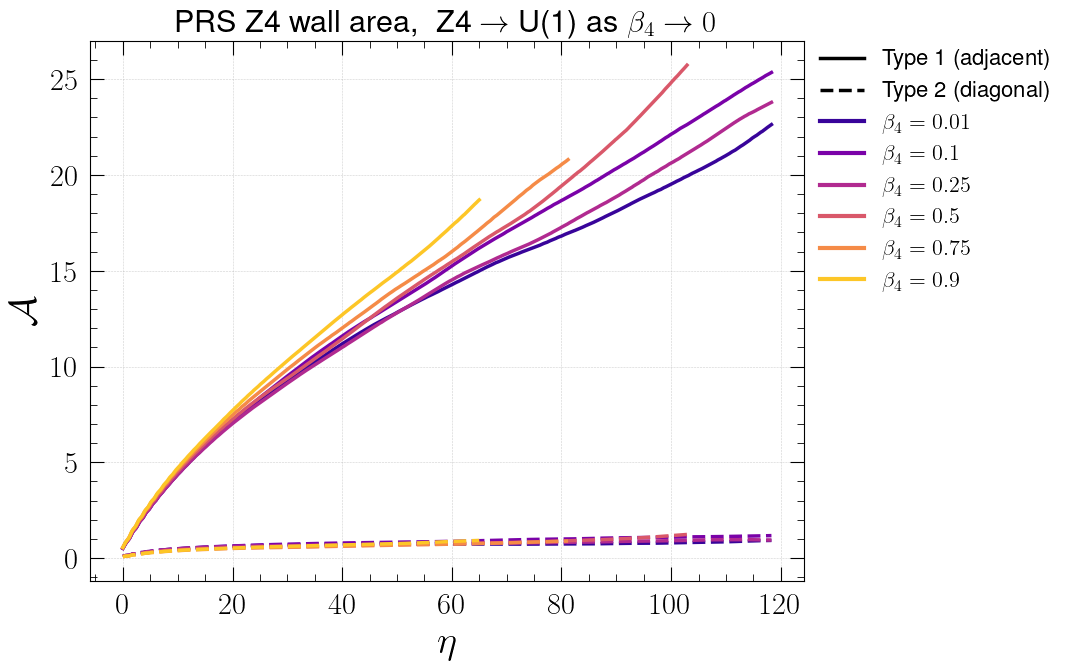

In [6]:
fig, ax = plt.subplots(figsize=(11, 7))

for d in ready:
    c = d["color"]
    eta1, A1 = area_param("scal1", d)
    eta2, A2 = area_param("scal2", d)
    ax.plot(eta1, A1, color=c, linestyle="solid",  linewidth=d["lw"])
    ax.plot(eta2, A2, color=c, linestyle="dashed", linewidth=d["lw"])

type_handles = [
    Line2D([0], [0], color='k', lw=2.5, linestyle='solid',  label='Type 1 (adjacent)'),
    Line2D([0], [0], color='k', lw=2.5, linestyle='dashed', label='Type 2 (diagonal)'),
]
paper_ax(ax, ylabel=r"$\mathcal{A}$",
         title=r"PRS Z4 wall area,\; Z4 $\to$ U(1) as $\beta_4 \to 0$")
ax.legend(handles=type_handles + beta4_handles(), fontsize=16, frameon=False,
          loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
plt.tight_layout()
plt.savefig("Z4_prs_both_walls.pdf", bbox_inches="tight")
plt.show()

## β₄ sweep — type 1 vs type 2 side by side

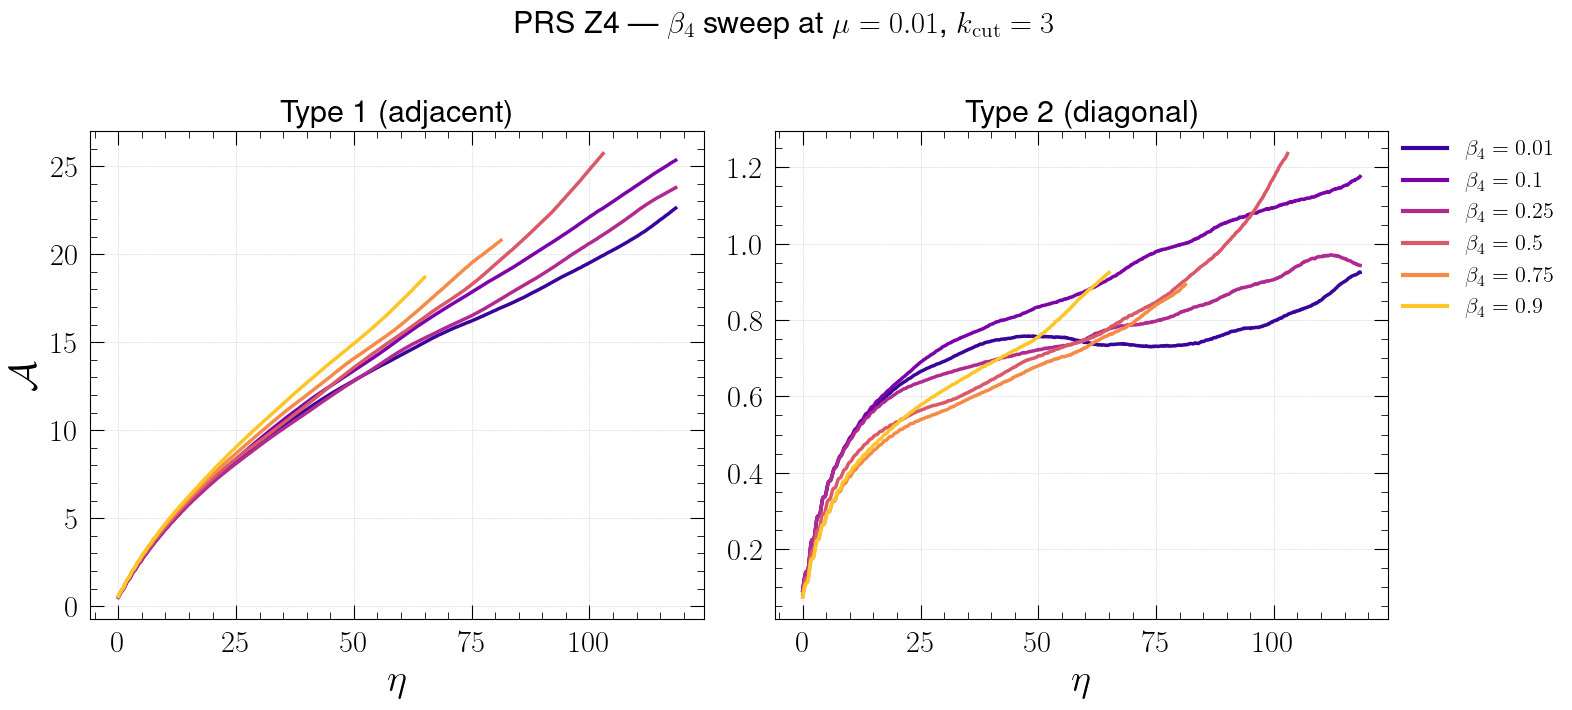

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=False)

for d in ready:
    c = d["color"]
    for ax_idx, key in enumerate(["scal1", "scal2"]):
        eta, A = area_param(key, d)
        axes[ax_idx].plot(eta, A, color=c, linewidth=d["lw"])

for ax_idx, title in enumerate(["Type 1 (adjacent)", "Type 2 (diagonal)"]):
    paper_ax(axes[ax_idx], ylabel=r"$\mathcal{A}$" if ax_idx == 0 else "", title=title)
axes[1].legend(handles=beta4_handles(), fontsize=16, frameon=False,
               loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)

fig.suptitle(r"PRS Z4 — $\beta_4$ sweep at $\mu = 0.01$, $k_{\rm cut}=3$", fontsize=22, y=1.02)
plt.tight_layout()
plt.savefig("Z4_prs_beta4_sweep.pdf", bbox_inches="tight")
plt.show()

## Ratio 𝒜₂ / 𝒜₁ — wall-type splitting diagnostic

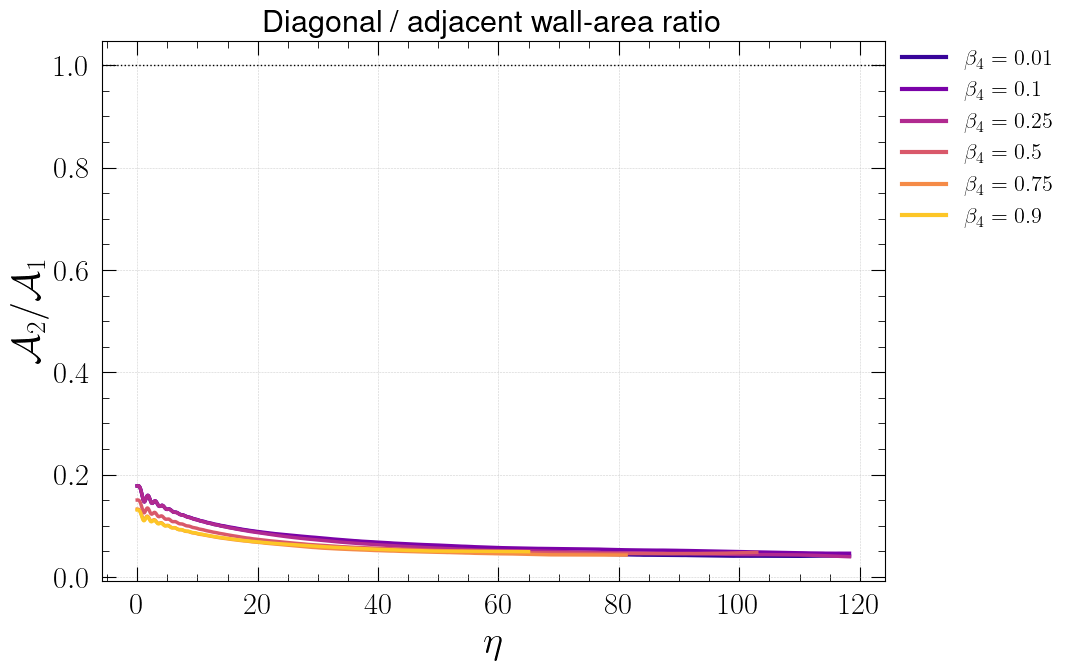

In [8]:
fig, ax = plt.subplots(figsize=(11, 7))

for d in ready:
    eta1, A1 = area_param("scal1", d)
    _,    A2 = area_param("scal2", d)
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = np.where(A1 != 0, A2 / A1, np.nan)
    ax.plot(eta1, ratio, color=d["color"], linewidth=d["lw"])

ax.axhline(1.0, color='k', lw=1, ls=':')
paper_ax(ax, ylabel=r"$\mathcal{A}_2/\mathcal{A}_1$",
         title=r"Diagonal / adjacent wall-area ratio")
ax.legend(handles=beta4_handles(), fontsize=16, frameon=False,
          loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
plt.tight_layout()
plt.savefig("Z4_prs_wall_ratio.pdf", bbox_inches="tight")
plt.show()

## Energy budget

Total energy and the three potential pieces: $V_1$ (mass), $V_2$ ($\lambda_1$ quartic),
$V_3$ ($\lambda_2$ Z4-breaking).

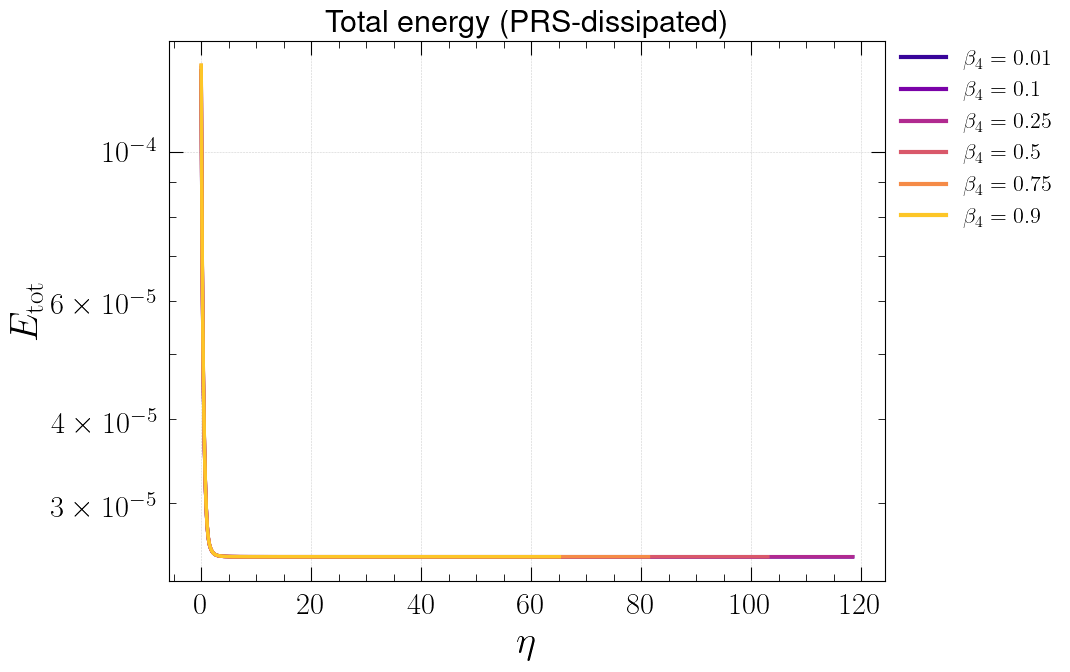

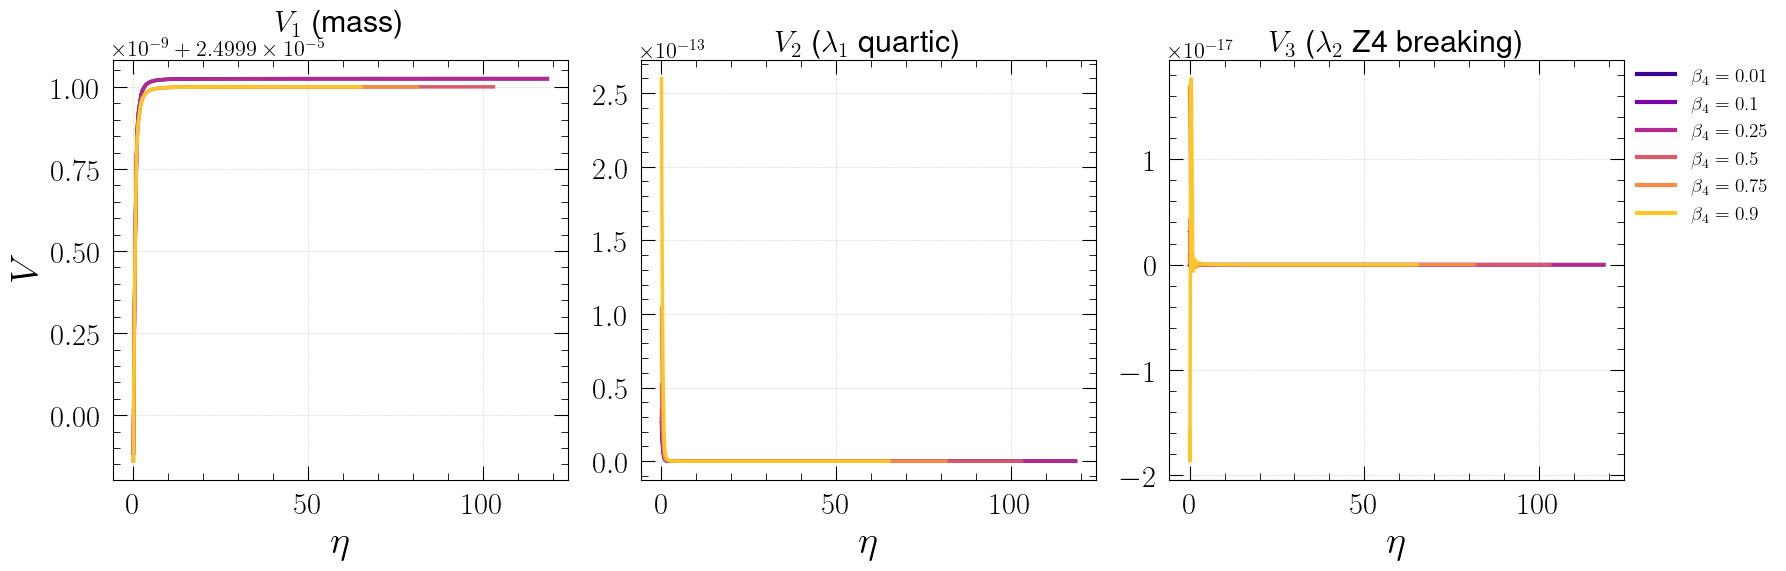

In [9]:
# ── Total energy ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))
for d in ready:
    en = d["energies"]
    ax.plot(en["eta"], en["E_tot"], color=d["color"], linewidth=d["lw"])
paper_ax(ax, ylabel=r"$E_{\rm tot}$", title="Total energy (PRS-dissipated)")
ax.set_yscale("log")
ax.legend(handles=beta4_handles(), fontsize=16, frameon=False,
          loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
plt.tight_layout()
plt.show()

# ── Potential components ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True)
for d in ready:
    en = d["energies"]
    for i, key in enumerate(["Ev_1", "Ev_2", "Ev_3"]):
        axes[i].plot(en["eta"], en[key], color=d["color"], linewidth=d["lw"])
for i, lbl in enumerate([r"$V_1$ (mass)", r"$V_2$ ($\lambda_1$ quartic)",
                          r"$V_3$ ($\lambda_2$ Z4 breaking)"]):
    paper_ax(axes[i], ylabel=r"$V$" if i == 0 else "", title=lbl)
axes[2].legend(handles=beta4_handles(), fontsize=14, frameon=False,
               loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
plt.tight_layout()
plt.show()

## Scalar-field means and RMS

Field 0 and field 1 (real/imag components of $\Phi$): volume-mean $\langle\phi\rangle$ and
RMS $\sqrt{\langle\phi^2\rangle}$.

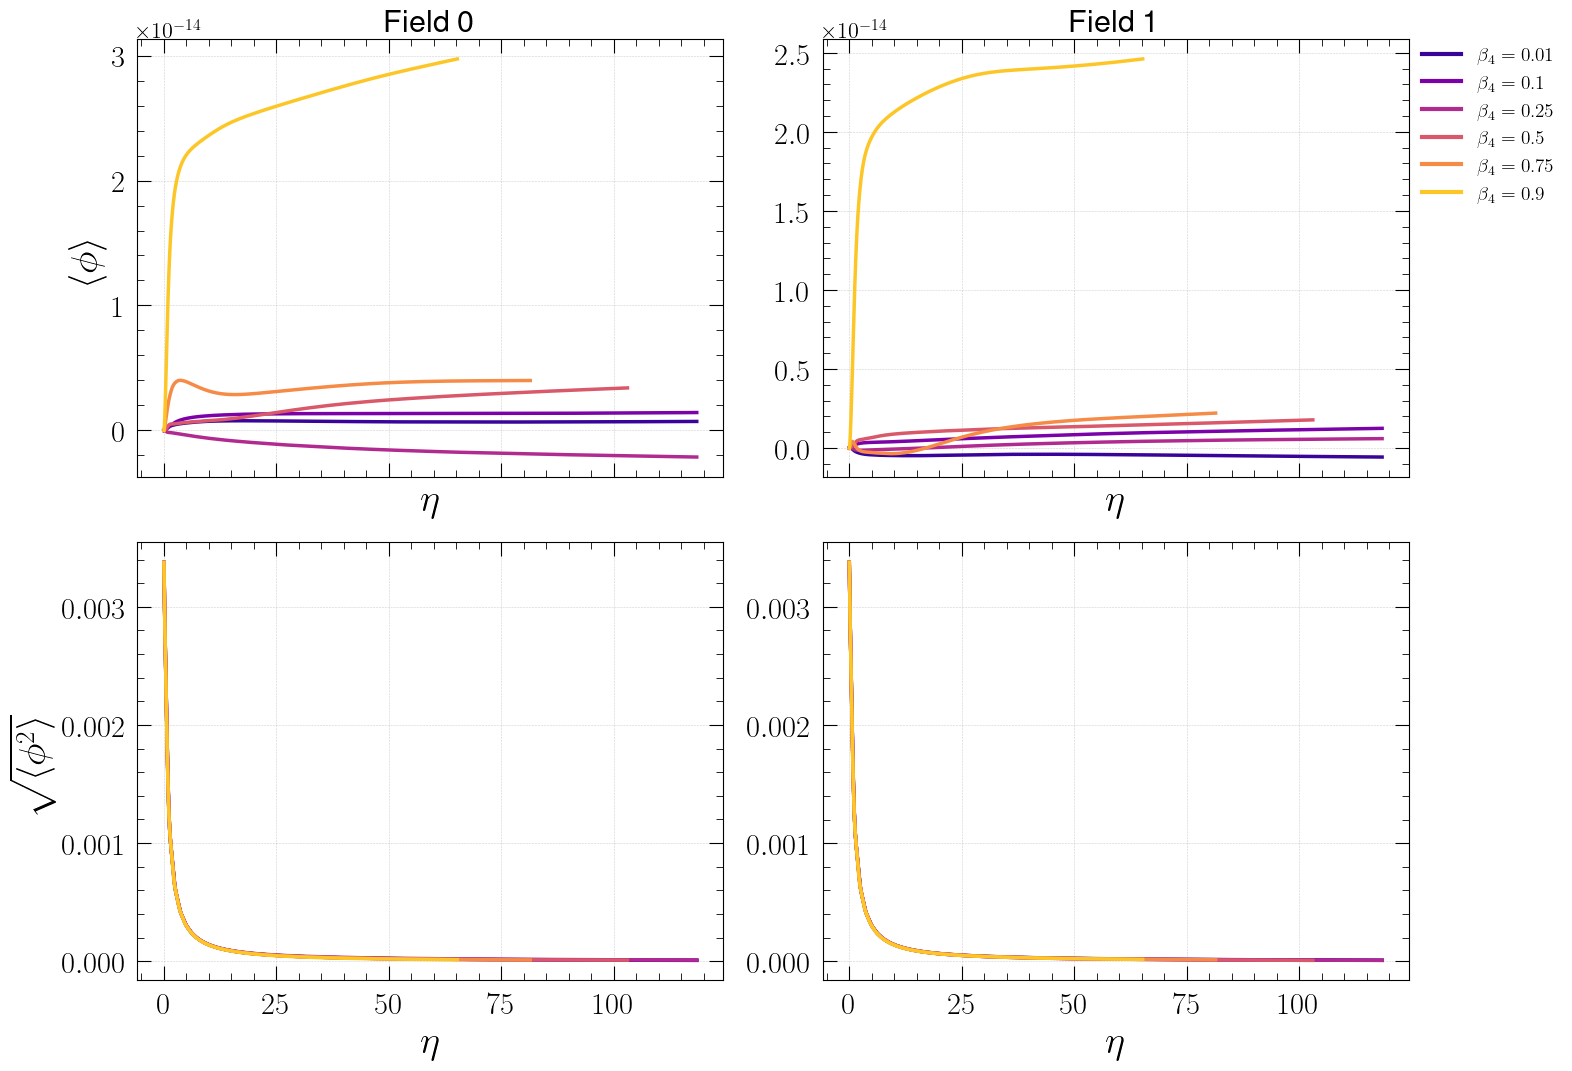

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11), sharex=True)
for d in ready:
    c = d["color"]
    for col, sk in enumerate(["scalar_0", "scalar_1"]):
        s = d[sk]
        if s is None:
            continue
        axes[0, col].plot(s["eta"], s["phi"],     color=c, linewidth=d["lw"])
        axes[1, col].plot(s["eta"], s["rms_phi"], color=c, linewidth=d["lw"])

axes[0, 0].set_title(r"Field 0", fontsize=22)
axes[0, 1].set_title(r"Field 1", fontsize=22)
for col in (0, 1):
    paper_ax(axes[0, col], ylabel=r"$\langle\phi\rangle$" if col == 0 else "")
    paper_ax(axes[1, col], ylabel=r"$\sqrt{\langle\phi^2\rangle}$" if col == 0 else "")
axes[0, 1].legend(handles=beta4_handles(), fontsize=14, frameon=False,
                  loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
plt.tight_layout()
plt.savefig("Z4_prs_scalar_means.pdf", bbox_inches="tight")
plt.show()

## Scale factor & Hubble rate

Background is fixed (radiation, `fixedBackground=true`), so all runs share $a(\eta)=1+H_0\eta$;
this is a sanity check that the runs used the intended background.

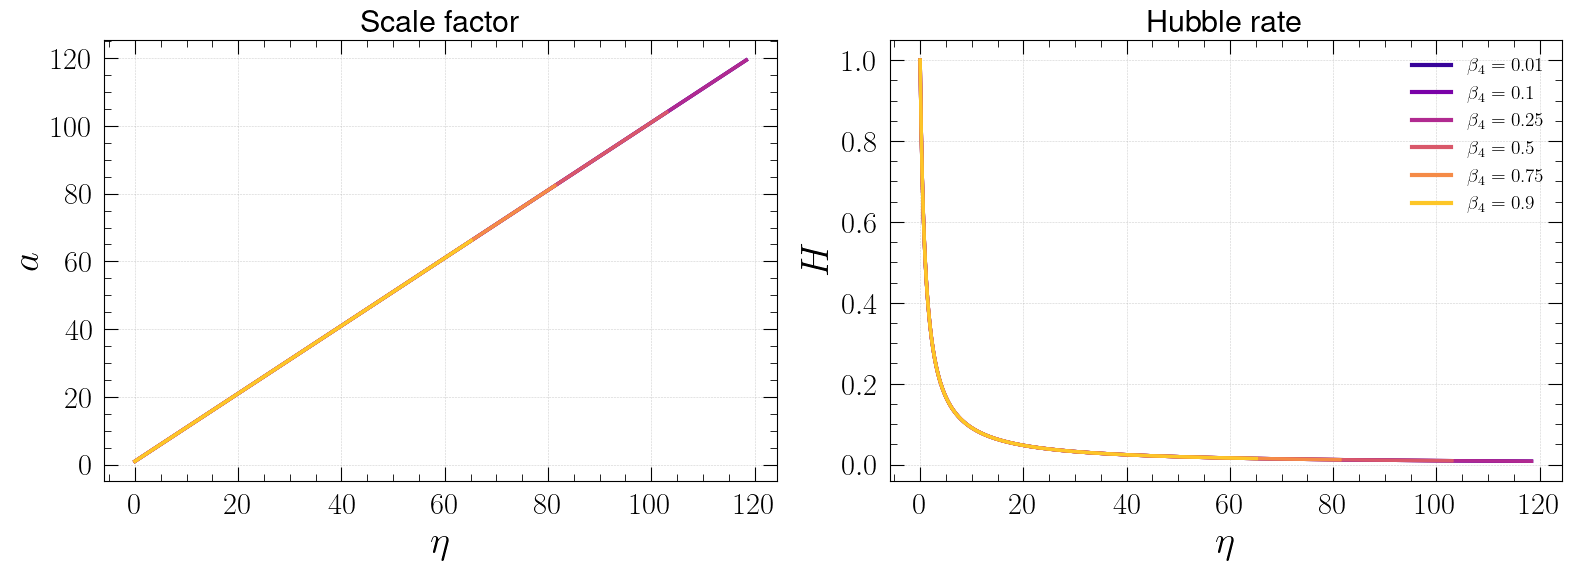

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for d in ready:
    sf = d["scale_factor"]
    axes[0].plot(sf["eta"], sf["a"], color=d["color"], linewidth=d["lw"])
    axes[1].plot(sf["eta"], sf["H"], color=d["color"], linewidth=d["lw"])
paper_ax(axes[0], ylabel=r"$a$", title="Scale factor")
paper_ax(axes[1], ylabel=r"$H$", title="Hubble rate")
axes[1].legend(handles=beta4_handles(), fontsize=14, frameon=False,
               loc='upper right')
plt.tight_layout()
plt.show()

## Resolution check (PRS fixes the comoving wall width)

Each box was sized to `N_PTS_WALL` grid points across the thinnest wall. Under `prsWall=true`
the comoving width is held fixed, so `pts/wall` is **constant in time**. The last column shows
what `pts/wall` would have collapsed to at `tMax` *without* PRS (∝ 1/a) — the reason PRS is needed.

In [12]:
print(f"{'beta_4':>7s} {'lSide':>8s} {'dx':>7s} "
      f"{'d_adj':>6s} {'d_opp':>6s} {'d_min':>6s} "
      f"{'pts/wall (PRS)':>15s} {'pts/wall @tMax noPRS':>22s}")
print("-" * 92)
for d in ready:
    b   = d["beta4"]
    sf  = d["scale_factor"]
    dx  = d["dx"]
    dmin = delta_min(b)
    pts_prs = dmin / dx if dx else np.nan          # constant under PRS
    a_end   = sf["a"][-1]
    pts_noprs = pts_prs / a_end                     # what it'd be without the fat-wall scheme
    print(f"{b:7.2f} {d['lside']:8.2f} {dx:7.4f} "
          f"{delta_adj(b):6.3f} {DELTA_OPP:6.3f} {dmin:6.3f} "
          f"{pts_prs:15.2f} {pts_noprs:22.3f}")

 beta_4    lSide      dx  d_adj  d_opp  d_min  pts/wall (PRS)   pts/wall @tMax noPRS
--------------------------------------------------------------------------------------------
   0.01   358.40  0.7000  6.530  1.400  1.400            2.00                  0.017
   0.10   358.40  0.7000  2.380  1.400  1.400            2.00                  0.017
   0.25   358.40  0.7000  1.571  1.400  1.400            2.00                  0.017
   0.50   312.24  0.6098  1.220  1.400  1.220            2.00                  0.019
   0.75   281.11  0.5490  1.098  1.400  1.098            2.00                  0.024
   0.90   278.26  0.5435  1.087  1.400  1.087            2.00                  0.030


### Notes & caveats

- **Use 𝒜 only** from these runs (geometric wall area from `ZNvacuumPhase`). It is valid under PRS.
- **σ and GW-UV are unphysical** here (physical wall width grows ∝ a). Take σ from the static-BVP
  tensions: `sigma_phys = sigma_bar · mu^3 / lambda1`, with `sigma_bar = SIGMA_ADJ[beta_4]`
  (adjacent) or `1/√2` (diagonal). For GW spectra, re-run with `prsWall=false` (fixed physical width).
- Boxes and `tMax` differ per `beta_4` (sized on the thinnest wall); 𝒜 = scal/(2aH) is box-size
  independent, so curves are directly comparable.
- To regenerate cards / re-run: `analysis/wall_width_box_calculator_Z4.ipynb` →
  `buildZ4_stable/runner_stable.sh`. See `PRS_FRICTION_NOTES.md`.